<a href="https://colab.research.google.com/github/ralucamicu/FineTuning-LLMs-for-Cybersecurity-Knowledge/blob/master/finetune_gemma_mitre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning Gemma for MITRE ATT&CK Command Classification

**Dissertation Project — Second Case Study**
**Author:** Raluca Micu
**Scientific coordinators:** Conf. dr. ing. Titus Bălan, Ing. Vlad Dinu

---

## Goal

Fine-tune a small Gemma model to classify Linux command lines according to the **MITRE ATT&CK** framework. Given a single command, the model predicts either:
- a specific MITRE technique ID (e.g., `T1059.001`, `T1105`, `T1003.001`), or
- `BENIGN` if the command is non-malicious.

This complements the spear-phishing classifier (the project's first case study): the same fine-tuning + Ollama deployment pattern is reused, but applied to a fundamentally different domain — process-level system events instead of email content.

## Why this matters

A binary "good vs. bad" classifier tells a SOC analyst that *something* is suspicious. A MITRE-technique classifier tells them *what kind of attack* is being attempted (initial access, persistence, lateral movement, etc.), which determines the appropriate defensive response. This converts an alert into actionable intelligence.

## Dataset

**Source:** [mouna23/AI-driven-MITRE-Attack](https://github.com/mouna23/AI-driven-MITRE-Attack) — `dataset_full_160k.csv`

| Column | Description |
|---|---|
| `commandline` | The raw Linux command line (input feature) |
| `mitre_label` | The ground-truth label — either a MITRE technique ID or `BENIGN` (target) |

The dataset contains ~80,000 benign commands and ~80,000 malicious commands distributed across a small set of common MITRE techniques.

## Base model: Gemma 3 270M

Following the supervisor's recommendation to use "a super tiny Gemma model", we use **Gemma 3 270M** — the smallest model in the Gemma 3 family. At only 270 million parameters, it is:
- Fast to train (~10–15 minutes on a T4 GPU)
- Fast to run (~50–100 ms per command on commodity hardware)
- Small enough (~500 MB) to deploy on edge devices, in containers, or as an agent on every endpoint

This is intentionally a different model than the Llama-3.2-3B used for spear-phishing — the dissertation compares not only different domains, but also different model scales suited to different operational constraints.

## Hardware

Free-tier Google Colab T4 GPU is sufficient. Total runtime ~30–45 minutes.


## 1. Environment Setup

In [1]:
# Verify GPU
import torch
assert torch.cuda.is_available(), "No GPU detected. Runtime → Change runtime type → T4 GPU."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}")
print(f"VRAM: {gpu.total_memory / 1024**3:.1f} GB")

GPU: Tesla T4
VRAM: 14.6 GB


In [2]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth
!pip install -qU scikit-learn pandas matplotlib seaborn

In [3]:
import json, re, random, gc
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

random.seed(3407)
np.random.seed(3407)
torch.manual_seed(3407)
print("Setup complete.")

Setup complete.


## 2. Load the MITRE ATT&CK Dataset

In [4]:
!rm -rf /content/AI-driven-MITRE-Attack
!git clone --depth=1 https://github.com/mouna23/AI-driven-MITRE-Attack.git /content/AI-driven-MITRE-Attack
!ls /content/AI-driven-MITRE-Attack/data/

Cloning into '/content/AI-driven-MITRE-Attack'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 6.81 MiB | 9.97 MiB/s, done.
dataset_full_160k.csv  readme.md


In [5]:
DATA_PATH = "/content/AI-driven-MITRE-Attack/data/dataset_full_160k.csv"
df = pd.read_csv(DATA_PATH)

print(f"Total samples: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nExample rows:")
print(df.head())

/tmp/ipykernel_1845/792443030.py:2: DtypeWarning: Columns (0: dest_ip, 1: file_hash) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Total samples: 160,000

Columns: ['timestamp', 'host', 'user', 'parent_process', 'commandline', 'process_name', 'source_ip', 'dest_ip', 'file_hash', 'raw_message', 'event_type', 'mitre_label', 'mitre_name']

Example rows:
                     timestamp       host        user  parent_process  \
0  2025-11-14T02:03:35.943650Z  host-0132        john    explorer.exe   
1  2025-11-15T15:37:41.943650Z  host-1598  svc_backup         cmd.exe   
2  2025-11-17T03:32:32.943650Z  host-0013        john     svchost.exe   
3  2025-11-12T14:29:33.943650Z  host-1788       alice  powershell.exe   
4  2025-11-16T18:40:41.943650Z  host-1104     svc_net     svchost.exe   

                                         commandline process_name   source_ip  \
0  powershell -c "New-Object System.Net.Sockets.T...   powershell  10.0.5.193   
1                           svchost.exe -k {service}  svchost.exe   10.0.2.64   
2  if ((Get-WmiObject -Class Win32_ComputerSystem...           if   10.0.4.40   
3              

Class distribution:
mitre_label
BENIGN       80000
T1059.001     2707
T1036.005     2679
T1027         2668
T1563.002     2641
T1071.001     2636
T1562.001     2633
T1567.002     2628
T1055         2627
T1105         2624
T1047         2621
T1569.002     2620
T1486         2609
T1497         2601
T1490         2588
T1041         2586
T1566.001     2581
T1568.002     2579
T1218.011     2577
T1574.001     2568
T1112         2558
T1059.003     2555
T1053.005     2545
T1136         2538
T1003         2525
T1070.004     2525
T1020         2519
T1547.001     2508
T1210         2505
T1499         2496
T1005         2489
T1082         2464
Name: count, dtype: int64

Total classes: 32


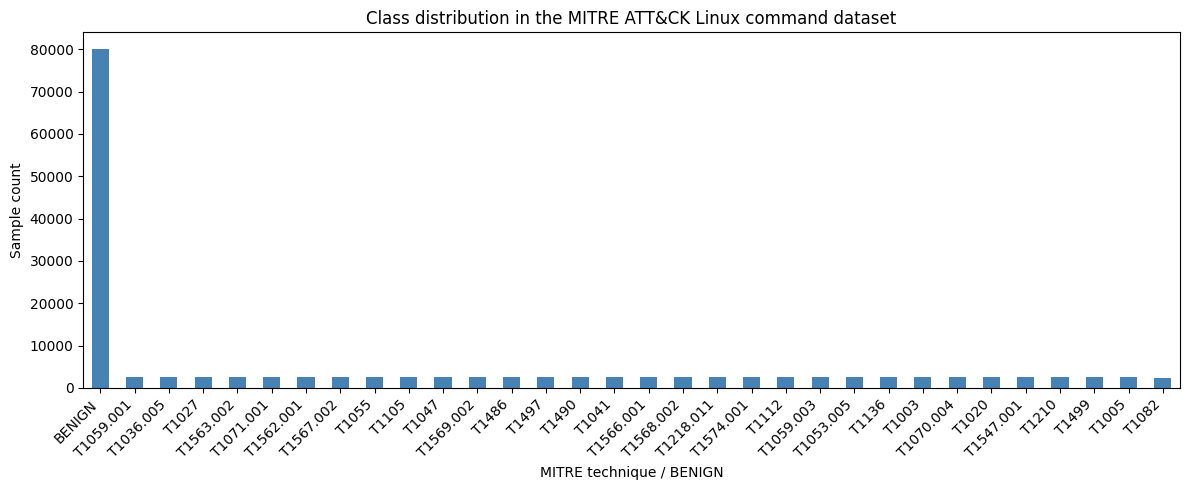

In [6]:
print("Class distribution:")
class_counts = df['mitre_label'].value_counts()
print(class_counts)
print(f"\nTotal classes: {len(class_counts)}")

plt.figure(figsize=(12, 5))
class_counts.plot(kind='bar', color='steelblue')
plt.xlabel("MITRE technique / BENIGN")
plt.ylabel("Sample count")
plt.title("Class distribution in the MITRE ATT&CK Linux command dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("mitre_class_distribution.png", dpi=150)
plt.show()

In [7]:
MIN_SAMPLES_PER_CLASS = 50

keep_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
df_filtered = df[df['mitre_label'].isin(keep_classes)].reset_index(drop=True)

print(f"Classes kept: {len(keep_classes)}")
print(f"Samples kept: {len(df_filtered):,} / {len(df):,}")
print(f"\nFinal classes:")
print(df_filtered['mitre_label'].value_counts())

Classes kept: 32
Samples kept: 160,000 / 160,000

Final classes:
mitre_label
BENIGN       80000
T1059.001     2707
T1036.005     2679
T1027         2668
T1563.002     2641
T1071.001     2636
T1562.001     2633
T1567.002     2628
T1055         2627
T1105         2624
T1047         2621
T1569.002     2620
T1486         2609
T1497         2601
T1490         2588
T1041         2586
T1566.001     2581
T1568.002     2579
T1218.011     2577
T1574.001     2568
T1112         2558
T1059.003     2555
T1053.005     2545
T1136         2538
T1003         2525
T1070.004     2525
T1020         2519
T1547.001     2508
T1210         2505
T1499         2496
T1005         2489
T1082         2464
Name: count, dtype: int64


## 3. Train / Validation / Test Split

In [8]:
# 70 / 15 / 15 stratified split
train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.30,
    stratify=df_filtered['mitre_label'],
    random_state=3407,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['mitre_label'],
    random_state=3407,
)

print(f"Train: {len(train_df):,}  | Val: {len(val_df):,}  | Test: {len(test_df):,}")

label_to_id = {label: idx for idx, label in enumerate(sorted(df_filtered['mitre_label'].unique()))}
id_to_label = {idx: label for label, idx in label_to_id.items()}
NUM_CLASSES = len(label_to_id)

print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Label → ID mapping:")
for label, idx in label_to_id.items():
    print(f"  {idx:2d} → {label}")

Train: 112,000  | Val: 24,000  | Test: 24,000

Number of classes: 32
Label → ID mapping:
   0 → BENIGN
   1 → T1003
   2 → T1005
   3 → T1020
   4 → T1027
   5 → T1036.005
   6 → T1041
   7 → T1047
   8 → T1053.005
   9 → T1055
  10 → T1059.001
  11 → T1059.003
  12 → T1070.004
  13 → T1071.001
  14 → T1082
  15 → T1105
  16 → T1112
  17 → T1136
  18 → T1210
  19 → T1218.011
  20 → T1486
  21 → T1490
  22 → T1497
  23 → T1499
  24 → T1547.001
  25 → T1562.001
  26 → T1563.002
  27 → T1566.001
  28 → T1567.002
  29 → T1568.002
  30 → T1569.002
  31 → T1574.001


## 4. Load the Base Model — Gemma 3 270M


In [36]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 1024
BASE_MODEL = "unsloth/gemma-2-2b-it-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,   # 2B needs 4-bit on T4
)
print(f"Loaded {BASE_MODEL}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

==((====))==  Unsloth 2026.5.10: Fast Gemma2 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.


Loaded unsloth/gemma-2-2b-it-bnb-4bit
Parameters: 1,602,203,904
VRAM after load: 2.63 GB


## 5. Define the Prompts and the Evaluator


In [10]:
VALID_LABELS = sorted(label_to_id.keys())
LABEL_LIST_STR = ", ".join(VALID_LABELS)

SYSTEM_PROMPT = (
    "You are a cybersecurity analyst classifying Linux commands according to the "
    "MITRE ATT&CK framework. For each command, respond with exactly one label from "
    f"this set: {LABEL_LIST_STR}. Use 'BENIGN' for non-malicious commands."
)

USER_PROMPT_TEMPLATE = (
    "Classify the following Linux command line:\n\n"
    "{cmd}\n\n"
    "Respond with exactly one label from the valid set."
)


def build_messages(cmd):
    return [
        {"role": "user", "content": f"{SYSTEM_PROMPT}\n\n{USER_PROMPT_TEMPLATE.format(cmd=cmd)}"},
    ]


# a regex that matches any valid label (longest-first to handle T1059.001 before T1059)
_label_pattern = re.compile(
    r"\b(" + "|".join(re.escape(l) for l in sorted(VALID_LABELS, key=len, reverse=True)) + r")\b"
)


def extract_label(response):
    """Pull a valid MITRE label out of the model's output."""
    m = _label_pattern.search(response)
    return m.group(1) if m else None


def predict(cmd):
    """Run a single classification. Returns (predicted_label, raw_response)."""
    messages = build_messages(cmd)
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = 24,        # labels are short
            do_sample = False,          # deterministic
            pad_token_id = tokenizer.eos_token_id,
        )
    text = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return extract_label(text), text


def evaluate_on_df(eval_df, name="eval", sample_n=None):
    """Evaluate Gemma on a pandas DataFrame. Returns metrics dict + per-sample results."""
    FastLanguageModel.for_inference(model)

    if sample_n is not None and sample_n < len(eval_df):
        eval_df = eval_df.sample(n=sample_n, random_state=3407)

    y_true, y_pred, raw_outputs = [], [], []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"Evaluating ({name})"):
        pred, raw = predict(row["commandline"])
        if pred is None:
            pred = "UNKNOWN"
        y_pred.append(pred)
        y_true.append(row["mitre_label"])
        raw_outputs.append(raw)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', labels=VALID_LABELS, zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=VALID_LABELS, zero_division=0)

    parse_failures = sum(1 for p in y_pred if p == "UNKNOWN")

    metrics = {
        "accuracy":         float(acc),
        "f1_macro":         float(f1_macro),
        "f1_weighted":      float(f1_weighted),
        "parse_failure_pct": float(parse_failures / len(y_pred) * 100),
        "n_samples":        len(y_pred),
    }

    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:20s}: {v:.4f}")
        else:
            print(f"  {k:20s}: {v}")

    return metrics, list(zip(y_true, y_pred, raw_outputs))

## 6. Baseline Evaluation (no fine-tune)


In [11]:
print("=" * 60)
print("BASELINE — Gemma 3 270M with no MITRE fine-tuning")
print("=" * 60)
baseline_metrics, baseline_results = evaluate_on_df(test_df, name="baseline (test)", sample_n=500)

BASELINE — Gemma 3 270M with no MITRE fine-tuning


Evaluating (baseline (test)):   0%|          | 0/500 [00:00<?, ?it/s]


baseline (test) metrics:
  accuracy            : 0.0200
  f1_macro            : 0.0014
  f1_weighted         : 0.0009
  parse_failure_pct   : 1.0000
  n_samples           : 500


In [12]:
print("Baseline sample outputs:\n")
for truth, pred, raw in baseline_results[:5]:
    correct = '✓' if truth == pred else '✗'
    print(f"  [Truth: {truth:15s} | Predicted: {str(pred):15s}] {correct}")
    print(f"  Raw response: {raw.strip()[:200]}")
    print()

Baseline sample outputs:

  [Truth: BENIGN          | Predicted: T1005          ] ✗
  Raw response: T1005

  [Truth: T1574.001       | Predicted: T1005          ] ✗
  Raw response: T1005

  [Truth: BENIGN          | Predicted: T1005          ] ✗
  Raw response: T1005

  [Truth: T1499           | Predicted: T1005          ] ✗
  Raw response: T1005

  [Truth: BENIGN          | Predicted: T1005          ] ✗
  Raw response: T1005



## 7. Apply LoRA Adapters

In [13]:
torch.cuda.empty_cache(); gc.collect(); torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

VRAM after cleanup: 0.84 GB


In [14]:
import subprocess
try:
    import torchao
    from packaging.version import parse as parse_version
    if parse_version(torchao.__version__) < parse_version("0.16.0"):
        print(f"Detected torchao version {torchao.__version__}, upgrading to >=0.16.0")
        subprocess.check_call(['pip', 'install', '--upgrade', 'torchao'])
except ImportError:
    print("torchao not found, installing it.")
    subprocess.check_call(['pip', 'install', 'torchao'])

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total      = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.4f}%)")

Detected torchao version 0.10.0, upgrading to >=0.16.0


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Trainable: 3,796,992 / Total: 271,895,168 (1.3965%)


## 8. Format the Training Data


In [15]:
def format_for_training(row):
    """Convert one (command, label) pair into a chat-templated training example."""
    cmd = row["commandline"]
    label = row["mitre_label"]
    messages = [
        {"role": "user",      "content": f"{SYSTEM_PROMPT}\n\n{USER_PROMPT_TEMPLATE.format(cmd=cmd)}"},
        {"role": "assistant", "content": label},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

TRAIN_SUBSAMPLE = 30000 # could also be full 112k but would take 45 mins

# Fix for KeyError: 'mitre_label' - explicitly concatenate sampled groups
sampled_groups = []
for label_value, group in train_df.groupby('mitre_label'):
    n_samples = min(len(group), TRAIN_SUBSAMPLE // NUM_CLASSES)
    if n_samples > 0:
        sampled_group = group.sample(n=n_samples, random_state=3407)
        sampled_groups.append(sampled_group)

if sampled_groups:
    train_subsample = pd.concat(sampled_groups).reset_index(drop=True)
else:
    train_subsample = pd.DataFrame(columns=train_df.columns) # Create empty dataframe if no samples

print(f"Training subsample: {len(train_subsample):,} examples")
print(f"Per-class counts:")
print(train_subsample['mitre_label'].value_counts())

train_records = [format_for_training(row) for _, row in train_subsample.iterrows()]
train_dataset = Dataset.from_list(train_records)
print(f"\nFirst training example:\n")
print(train_dataset[0]["text"])

Training subsample: 29,984 examples
Per-class counts:
mitre_label
BENIGN       937
T1003        937
T1005        937
T1020        937
T1027        937
T1036.005    937
T1041        937
T1047        937
T1053.005    937
T1055        937
T1059.001    937
T1059.003    937
T1070.004    937
T1071.001    937
T1082        937
T1105        937
T1112        937
T1136        937
T1210        937
T1218.011    937
T1486        937
T1490        937
T1497        937
T1499        937
T1547.001    937
T1562.001    937
T1563.002    937
T1566.001    937
T1567.002    937
T1568.002    937
T1569.002    937
T1574.001    937
Name: count, dtype: int64

First training example:

<bos><start_of_turn>user
You are a cybersecurity analyst classifying Linux commands according to the MITRE ATT&CK framework. For each command, respond with exactly one label from this set: BENIGN, T1003, T1005, T1020, T1027, T1036.005, T1041, T1047, T1053.005, T1055, T1059.001, T1059.003, T1070.004, T1071.001, T1082, T1105, T1112, T1136

## 9. Fine-Tune the Model

In [16]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,     # effective batch = 16
        warmup_steps = 30,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 50,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        save_strategy = "no",
        report_to = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part    = "<start_of_turn>model\n",
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/29984 [00:00<?, ? examples/s]

Map (num_proc=5):   0%|          | 0/29984 [00:00<?, ? examples/s]

Filter (num_proc=5):   0%|          | 0/29984 [00:00<?, ? examples/s]

In [17]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print(f"VRAM before training: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
trainer_stats = trainer.train()
print(f"\nPeak VRAM during training: {torch.cuda.max_memory_reserved()/1024**3:.2f} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 29,984 | Num Epochs = 1 | Total steps = 1,874
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 3,796,992 of 271,895,168 (1.40% trained)


VRAM before training: 0.85 GB


Step,Training Loss
50,0.706874
100,0.388814
150,0.237017
200,0.072128
250,0.030947
300,0.019865
350,0.019081
400,0.008983
450,0.004735
500,0.000570



Peak VRAM during training: 14.29 GB
Training time: 62.4 minutes


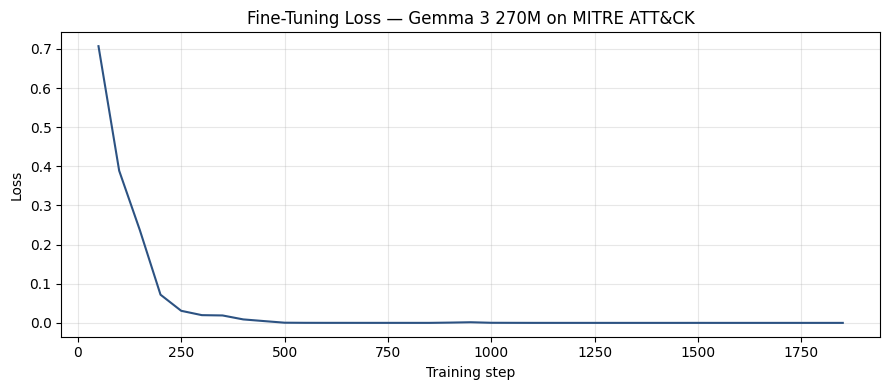

In [18]:
loss_history = trainer.state.log_history
losses = [(h["step"], h["loss"]) for h in loss_history if "loss" in h]
if losses:
    steps, vals = zip(*losses)
    plt.figure(figsize=(9, 4))
    plt.plot(steps, vals, linewidth=1.5, color="#2c5282")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Fine-Tuning Loss — Gemma 3 270M on MITRE ATT&CK")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("mitre_training_loss.png", dpi=150)
    plt.show()

## 10. Evaluation After Fine-Tuning


In [19]:
print("=" * 60)
print("AFTER FINE-TUNING — Gemma 3 270M on MITRE ATT&CK")
print("=" * 60)
ft_metrics, ft_results = evaluate_on_df(test_df, name="fine-tuned (test)", sample_n=2000)

AFTER FINE-TUNING — Gemma 3 270M on MITRE ATT&CK


Evaluating (fine-tuned (test)):   0%|          | 0/2000 [00:00<?, ?it/s]


fine-tuned (test) metrics:
  accuracy            : 1.0000
  f1_macro            : 1.0000
  f1_weighted         : 1.0000
  parse_failure_pct   : 0.0000
  n_samples           : 2000


In [30]:
train_cmds_set = set(train_df["commandline"])
test_unseen = test_df[~test_df["commandline"].isin(train_cmds_set)].reset_index(drop=True)
print(f"Truly unseen test commands: {len(test_unseen):,}")
print(f"Class distribution (unseen subset):")
print(test_unseen['mitre_label'].value_counts().head(10))

sample_size = min(500, len(test_unseen))
unseen_metrics, unseen_results = evaluate_on_df(
    test_unseen, name="unseen-only", sample_n=sample_size
)

Truly unseen test commands: 4,172
Class distribution (unseen subset):
mitre_label
BENIGN       1110
T1059.001     406
T1563.002     396
T1071.001     395
T1105         394
T1041         387
T1210         362
T1020         277
T1027         185
T1218.011     172
Name: count, dtype: int64


Evaluating (unseen-only):   0%|          | 0/500 [00:00<?, ?it/s]


unseen-only metrics:
  accuracy            : 1.0000
  f1_macro            : 0.3438
  f1_weighted         : 1.0000
  parse_failure_pct   : 0.0000
  n_samples           : 500


## 11. Compare Baseline vs. Fine-Tuned

In [20]:
rows = []
for metric in ["accuracy", "f1_macro", "f1_weighted", "parse_failure_pct"]:
    base_v = baseline_metrics[metric]
    ft_v   = ft_metrics[metric]
    delta  = ft_v - base_v
    rows.append({
        "Metric":     metric,
        "Baseline":   f"{base_v:.4f}",
        "Fine-tuned": f"{ft_v:.4f}",
        "Δ":          f"{delta:+.4f}",
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
df_compare.to_csv("mitre_before_after.csv", index=False)

           Metric Baseline Fine-tuned       Δ
         accuracy   0.0200     1.0000 +0.9800
         f1_macro   0.0014     1.0000 +0.9986
      f1_weighted   0.0009     1.0000 +0.9991
parse_failure_pct   1.0000     0.0000 -1.0000


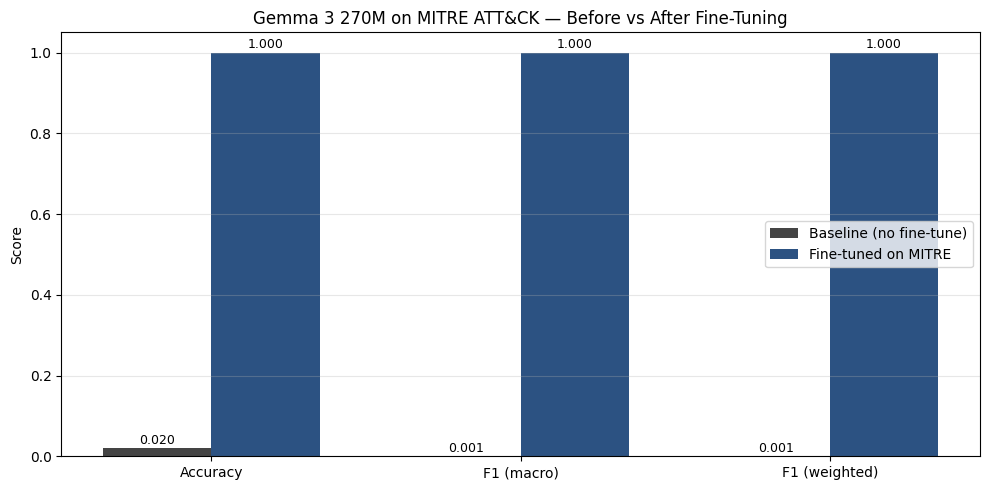

In [21]:
metric_names = ["accuracy", "f1_macro", "f1_weighted"]
metric_labels = ["Accuracy", "F1 (macro)", "F1 (weighted)"]
base_vals = [baseline_metrics[m] for m in metric_names]
ft_vals   = [ft_metrics[m]       for m in metric_names]

x = np.arange(len(metric_names)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, base_vals, width, label="Baseline (no fine-tune)", color="#444")
b2 = ax.bar(x + width/2, ft_vals,   width, label="Fine-tuned on MITRE",     color="#2c5282")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Gemma 3 270M on MITRE ATT&CK — Before vs After Fine-Tuning")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("mitre_before_after.png", dpi=150)
plt.show()

In [22]:

y_true_ft = [r[0] for r in ft_results]
y_pred_ft = [r[1] for r in ft_results]

print("Per-class classification report:\n")
print(classification_report(y_true_ft, y_pred_ft, labels=VALID_LABELS, zero_division=0))

Per-class classification report:

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       986
       T1003       1.00      1.00      1.00        40
       T1005       1.00      1.00      1.00        36
       T1020       1.00      1.00      1.00        31
       T1027       1.00      1.00      1.00        34
   T1036.005       1.00      1.00      1.00        29
       T1041       1.00      1.00      1.00        31
       T1047       1.00      1.00      1.00        43
   T1053.005       1.00      1.00      1.00        29
       T1055       1.00      1.00      1.00        30
   T1059.001       1.00      1.00      1.00        38
   T1059.003       1.00      1.00      1.00        35
   T1070.004       1.00      1.00      1.00        38
   T1071.001       1.00      1.00      1.00        25
       T1082       1.00      1.00      1.00        28
       T1105       1.00      1.00      1.00        32
       T1112       1.00      1.00      1.00    

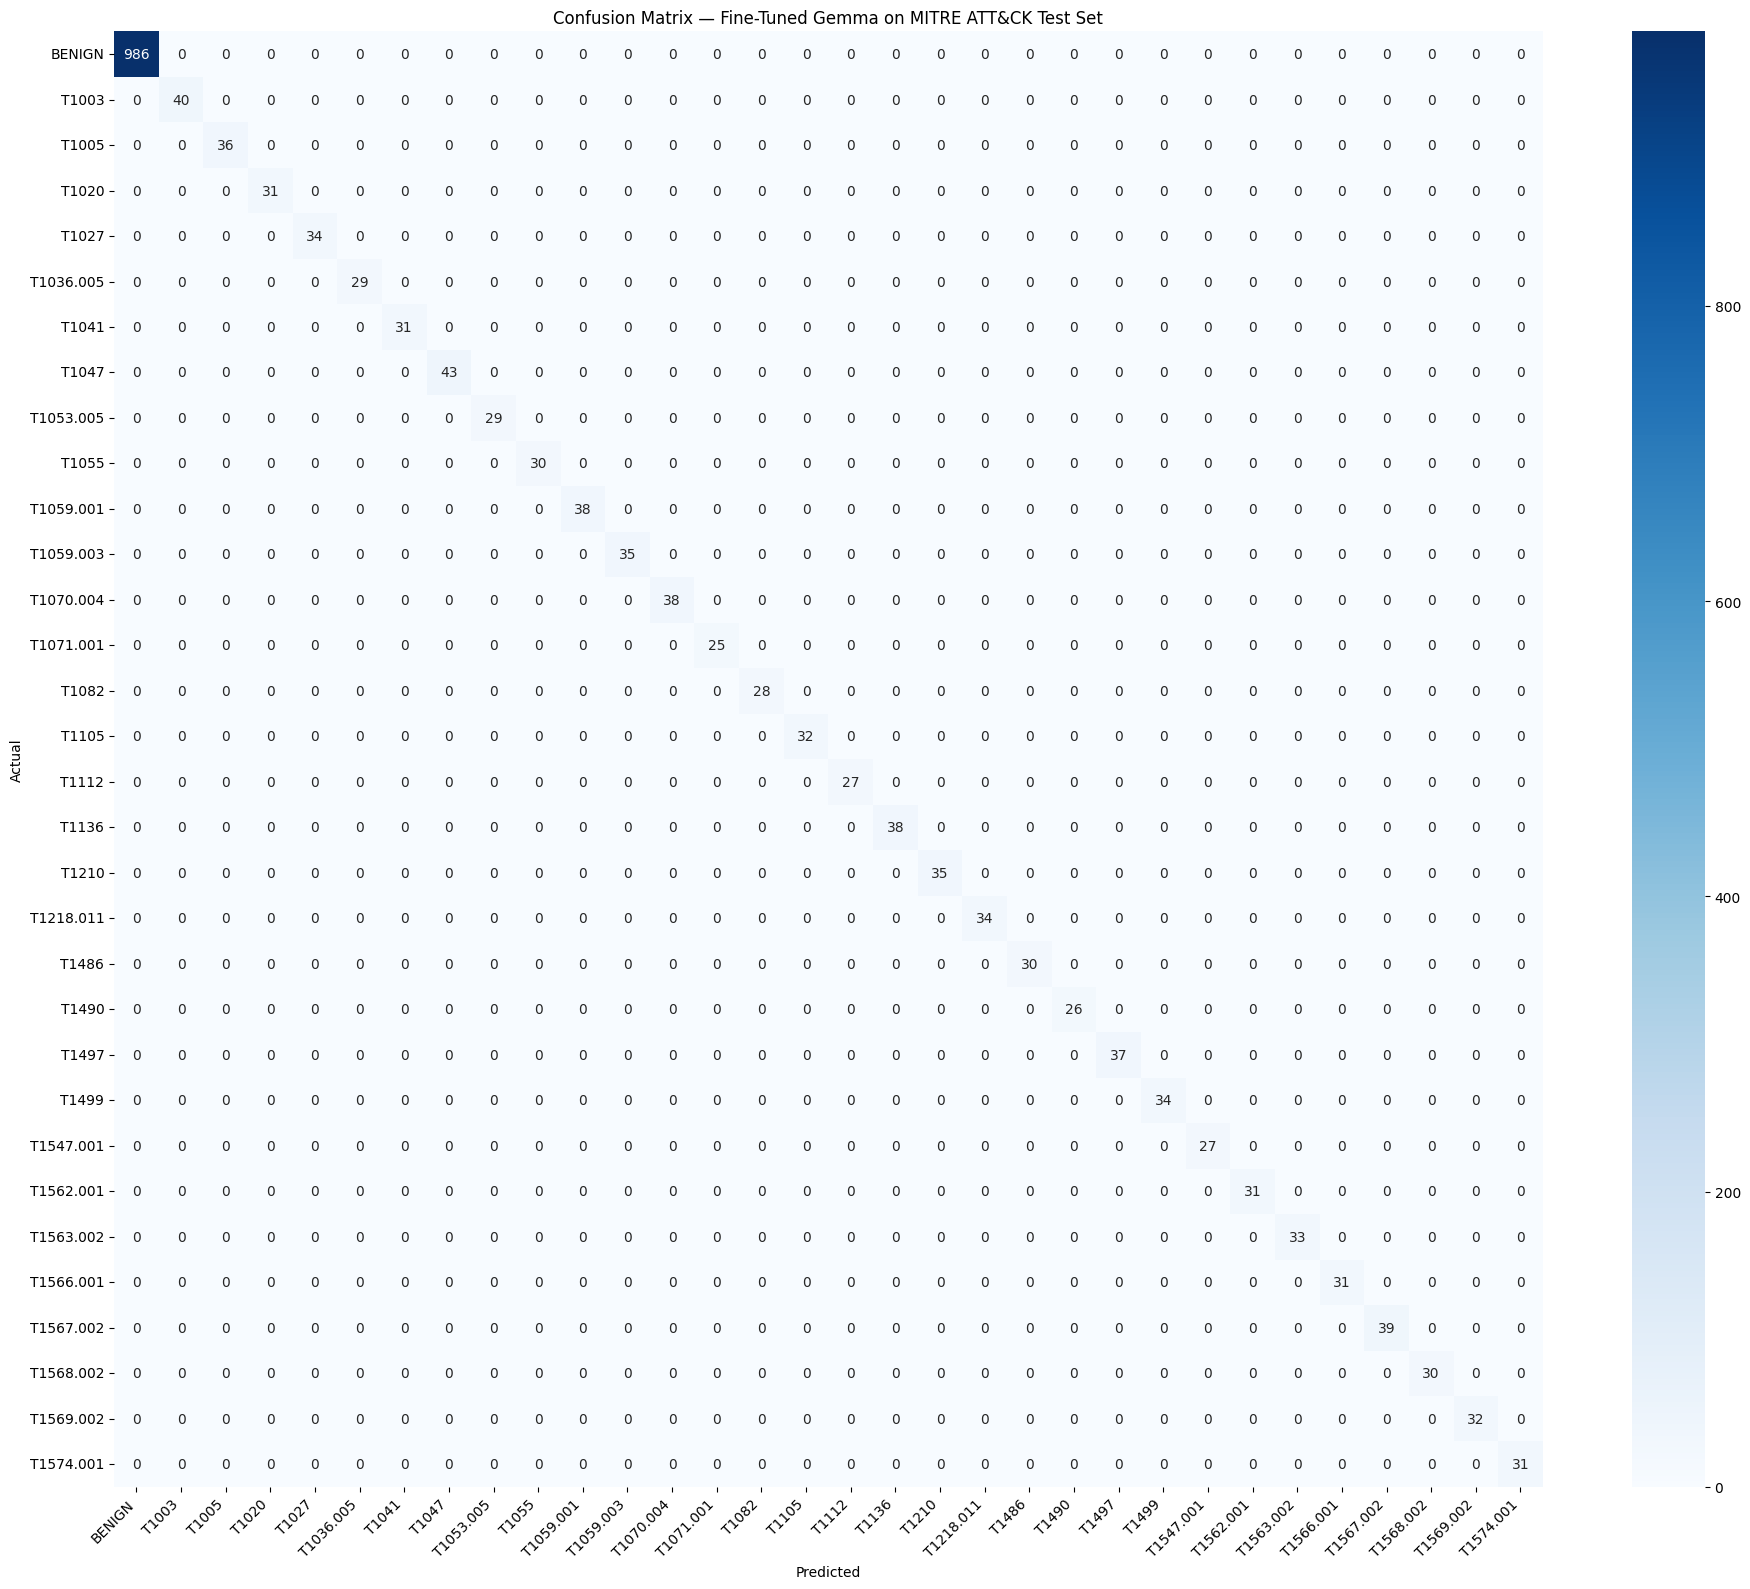

In [23]:
cm = confusion_matrix(y_true_ft, y_pred_ft, labels=VALID_LABELS)

plt.figure(figsize=(max(8, NUM_CLASSES*0.6), max(6, NUM_CLASSES*0.5)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=VALID_LABELS, yticklabels=VALID_LABELS, cbar=True)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Fine-Tuned Gemma on MITRE ATT&CK Test Set")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("mitre_confusion_matrix.png", dpi=150)
plt.show()

## 12. Save the Fine-Tuned Adapter

In [24]:
model.save_pretrained("gemma-2-2b-mitre-lora")
tokenizer.save_pretrained("gemma-2-2b-mitre-lora")
print("Saved LoRA adapter to ./gemma-2-2b-mitre-lora/")

Unsloth: Restored added_tokens_decoder metadata in gemma-3-270m-mitre-lora/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma-3-270m-mitre-lora.


Saved LoRA adapter to ./gemma-3-270m-mitre-lora/


In [25]:
results_df = pd.DataFrame(ft_results, columns=["truth", "predicted", "raw_output"])
results_df["is_correct"] = (results_df["truth"] == results_df["predicted"]).astype(int)
results_df.to_csv("mitre_per_sample.csv", index=False)
print(f"Saved {len(results_df)} per-sample results to mitre_per_sample.csv")
print(f"\nAccuracy: {results_df['is_correct'].mean():.2%}")

Saved 2000 per-sample results to mitre_per_sample.csv

Accuracy: 100.00%


## 13. Export to GGUF for Ollama Deployment


In [33]:
print("Exporting to GGUF (Q4_K_M quantization)...")
model.save_pretrained_gguf(
    "gemma-2-2b-mitre-gguf",
    tokenizer,
    quantization_method = "q4_k_m",   # 2B has enough redundancy for Q4_K_M
)

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Exporting to GGUF (Q8_0 quantization)...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `gemma-3-270m-mitre-gguf`: 100%|██████████| 1/1 [00:11<00:00, 11.06s/it]


Successfully copied all 1 files from cache to `gemma-3-270m-mitre-gguf`
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `gemma-3-270m-mitre-gguf`: 100%|██████████| 1/1 [00:00<00:00, 179.70it/s]


Successfully copied all 1 files from cache to `gemma-3-270m-mitre-gguf`


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:19<00:00, 19.32s/it]


Unsloth: Merge process complete. Saved to `/content/gemma-3-270m-mitre-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['gemma-3-270m-mitre-gguf_gguf/gemma-3-270m-it.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q8_0. This might take 10 minutes...


Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['gemma-3-270m-mitre-gguf_gguf/gemma-3-270m-it.Q8_0.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model gemma-3-270m-mitre-gguf_gguf/gemma-3-270m-it.Q8_0.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to gemma-3-270m-mitre-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f gemma-3-270m-mitre-gguf_gguf/Modelfile

Export done. Files:
total 549M
-rw-r--r-- 1 root root 1.7K Jun  2 21:17 chat_template.jinja
-rw-r--r-- 1 root root 1.8K Jun  2 21:17 config.json
-rw-r--r-- 1 root root  232 Jun  2 21:17 generation_config.json
-rw-r--r-- 1 root root 512M Jun  2 21:18 model.safetensors
-rw-r--r-- 1 root root 1.2M Jun  2 21:17 tokenizer_config.json
-rw-r--r-- 1 root root  32M Jun  2 21:17 tokenizer.json
-rw-r--r-- 1 root root 4.5M Jun  2 19:28 tokenizer.model


In [34]:
modelfile = f"""FROM ./gemma-3-270m-mitre-gguf

TEMPLATE \"\"\"{{{{ if .System }}}}<start_of_turn>user
{{{{ .System }}}}

{{{{ end }}}}{{{{ range $i, $_ := .Messages }}}}<start_of_turn>{{{{ if eq .Role "user" }}}}user{{{{ else }}}}model{{{{ end }}}}
{{{{ .Content }}}}<end_of_turn>
{{{{ end }}}}<start_of_turn>model
\"\"\"

SYSTEM \"\"\"{SYSTEM_PROMPT}\"\"\"

PARAMETER temperature 0
PARAMETER stop "<end_of_turn>"
"""

with open("Modelfile", "w") as f:
    f.write(modelfile)
print("Modelfile written. To import into Ollama on your local machine:")
print("  ollama create gemma-mitre -f Modelfile")
print("  ollama run gemma-mitre")

Modelfile written. To import into Ollama on your local machine:
  ollama create gemma-mitre -f Modelfile
  ollama run gemma-mitre


In [35]:
!ls -lh gemma-3-270m-mitre-gguf_gguf/

total 520M
-rw-r--r-- 1 root root 242M Jun  2 19:45 gemma-3-270m-it.Q4_K_M.gguf
-rw-r--r-- 1 root root 279M Jun  2 21:19 gemma-3-270m-it.Q8_0.gguf
-rw-r--r-- 1 root root  595 Jun  2 21:19 Modelfile
